# Course tools and Python foundations

**MECE 4520 · Fall 2026 · asynchronous foundations**

<a target="_blank" href="https://colab.research.google.com/github/changyaochen/MECE4520/blob/master/site/foundations/01-course-tools.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/>
</a>

This notebook introduces the small set of Python tools used throughout the course. It is not a comprehensive Python tutorial: the goal is to be comfortable loading, inspecting, selecting, filtering, and plotting engineering data.

**Learning objectives**

- Use NumPy arrays for basic numerical calculations.
- Load a public dataset into a Pandas DataFrame.
- Select columns and filter rows using clear, readable code.
- Make and interpret a simple engineering-data plot.

## 1. Set up the notebook

The next cell imports the Python tools used throughout the course and loads the pinned course copy of the gas-turbine dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from urllib.request import urlretrieve

DATA_URL = (
    "https://raw.githubusercontent.com/changyaochen/MECE4520/master/"
    "site/data/gas-turbine-emissions.csv"
)
data_path = next(
    (path for path in [Path("../data/gas-turbine-emissions.csv"), Path("site/data/gas-turbine-emissions.csv"), Path("gas-turbine-emissions.csv")] if path.exists()),
    Path("gas-turbine-emissions.csv"),
)
if not data_path.exists():
    urlretrieve(DATA_URL, data_path)
data = pd.read_csv(data_path)

plt.style.use("seaborn-v0_8-whitegrid")

## 2. Numerical arrays

A NumPy array stores a collection of numerical values. Array operations act element-by-element, which makes calculations compact and readable.

In [2]:
temperatures_c = np.array([15.2, 18.7, 21.4, 24.1])
temperatures_k = temperatures_c + 273.15

print("Temperatures in K:", temperatures_k)
print(f"Mean temperature: {temperatures_c.mean():.1f} °C")
print(f"Range: {temperatures_c.min():.1f}–{temperatures_c.max():.1f} °C")

Temperatures in K: [288.35 291.85 294.55 297.25]
Mean temperature: 19.9 °C
Range: 15.2–24.1 °C


The array is useful for a single quantity observed repeatedly. A table with many named variables is better represented by a Pandas **DataFrame**.

## 3. Load the course dataset

The Gas Turbine CO and NOx Emissions dataset contains hourly sensor measurements and emissions outcomes. `features` and `targets` are returned separately; combining them gives one analysis table.

In [3]:
print(f"Rows: {len(data):,}")
print(f"Columns: {data.shape[1]}")
data.head()

Rows: 36,733
Columns: 11


,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX
0,4.5878,1018.7,83.675,3.5758,23.979,1086.2,549.83,134.67,11.898,0.32663,81.952
1,4.2932,1018.3,84.235,3.5709,23.951,1086.1,550.05,134.67,11.892,0.44784,82.377
2,3.9045,1018.4,84.858,3.5828,23.990,1086.5,550.19,135.10,12.042,0.45144,83.776
3,3.7436,1018.3,85.434,3.5808,23.911,1086.5,550.17,135.03,11.990,0.23107,82.505
4,3.7516,1017.8,85.182,3.5781,23.917,1085.9,550.00,134.67,11.910,0.26747,82.028


A good first habit is to inspect the column names and units before modeling. The dictionary below records the variables we will use most often.

In [4]:
variable_notes = {
    "AT": "ambient temperature (°C)",
    "AP": "ambient pressure (mbar)",
    "AH": "ambient humidity (%)",
    "TIT": "turbine inlet temperature (°C)",
    "TEY": "turbine energy yield (MWh)",
    "CO": "carbon monoxide emissions (mg/m³)",
    "NOX": "nitrogen oxides emissions (mg/m³)",
}

pd.Series(variable_notes, name="meaning")

AT              ambient temperature (°C)
AP               ambient pressure (mbar)
AH                  ambient humidity (%)
TIT       turbine inlet temperature (°C)
TEY           turbine energy yield (MWh)
CO     carbon monoxide emissions (mg/m³)
NOX    nitrogen oxides emissions (mg/m³)
Name: meaning, dtype: object

## 4. Select and filter data

Use a list of column names to select several variables. Use a Boolean condition inside square brackets to retain rows meeting a condition.

In [5]:
selected = data[["AT", "TIT", "TEY", "CO", "NOX"]]
warm_conditions = selected[selected["AT"] > selected["AT"].median()]

print("Selected variables:")
display(selected.head())
print(f"Rows above the median ambient temperature: {len(warm_conditions):,}")
warm_conditions.describe().loc[["mean", "std", "min", "max"]]

Selected variables:


,AT,TIT,TEY,CO,NOX
0,4.5878,1086.2,134.67,0.32663,81.952
1,4.2932,1086.1,134.67,0.44784,82.377
2,3.9045,1086.5,135.10,0.45144,83.776
3,3.7436,1086.5,135.03,0.23107,82.505
4,3.7516,1085.9,134.67,0.26747,82.028


Rows above the median ambient temperature: 18,365


,AT,TIT,TEY,CO,NOX
mean,24.005367,1083.897964,132.012501,2.057256,59.22925
std,3.905948,15.765051,13.316517,1.602460,7.97456
min,17.802000,1024.800000,100.040000,0.001594,25.90500
max,37.103000,1100.900000,160.370000,37.746000,119.91000


## 5. Make a first plot

A scatter plot helps us inspect whether two variables move together. Each point below is one hourly observation. We draw only a random subset so the plot remains readable.

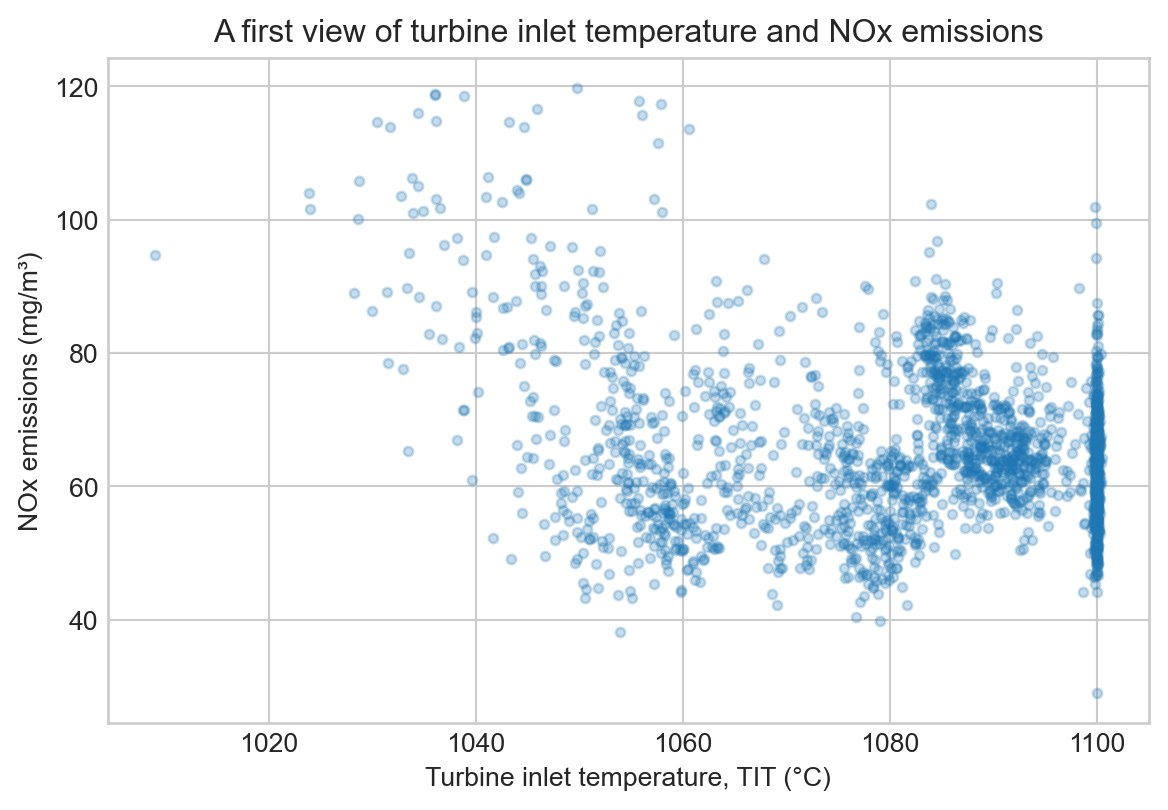

In [6]:
plot_data = data.sample(n=2_000, random_state=4520)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(plot_data["TIT"], plot_data["NOX"], alpha=0.25, s=12)
ax.set(
    xlabel="Turbine inlet temperature, TIT (°C)",
    ylabel="NOx emissions (mg/m³)",
    title="A first view of turbine inlet temperature and NOx emissions",
)
plt.show()

## Check-in

1. Change the plotting code to use `AT` or `TEY` on the horizontal axis. What pattern do you see?
2. What is one question you would ask before interpreting this plot as a causal relationship?
3. In one sentence, explain the difference between a NumPy array and a Pandas DataFrame.

Keep your answers in your own notes. We will build on this dataset in the next notebook.

[Return to the Foundations page](index.qmd)